(2140, 4)
           Home      Away  Home_Goals  Away_Goals
0     G-Olympus     Koban           2           3
1      Hirostar   Urawind           1           0
2        Nagomi  Shimizun           1           0
3  Savan Taurus  C-Osario           0           0
4      Sapporia     Iwana           0           0
Home_Goals mean: 1.4177570093457943
Away_Goals mean: 1.253271028037383


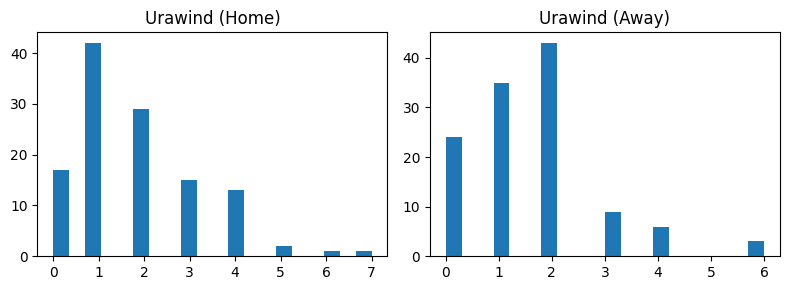

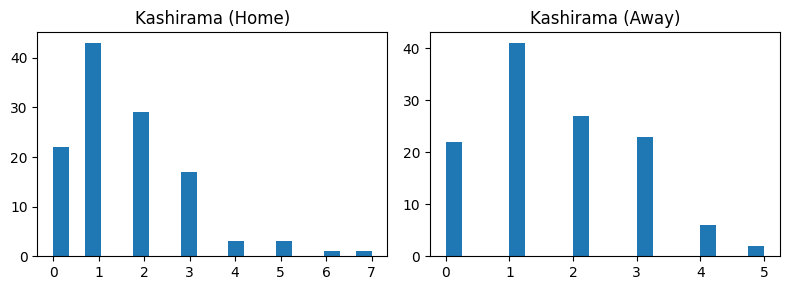

AIC m1: 6448.85770313588
AIC m2: 6472.639085015406
Best model: m1
                 Generalized Linear Model Regression Results                  
Dep. Variable:             Home_Goals   No. Observations:                 2140
Model:                            GLM   Df Residuals:                     2087
Model Family:                 Poisson   Df Model:                           52
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3171.4
Date:                Sat, 20 Sep 2025   Deviance:                       2433.7
Time:                        21:29:58   Pearson chi2:                 2.13e+03
No. Iterations:                    20   Pseudo R-squ. (CS):             0.1027
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

/var/folders/2_/gcncxwh97cz68wc2ysrfphg40000gn/T/ipykernel_34538/601018837.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred0 = float(best.predict(X0))
/var/folders/2_/gcncxwh97cz68wc2ysrfphg40000gn/T/ipykernel_34538/601018837.py:52: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred2 = float(best.predict(X2))
/var/folders/2_/gcncxwh97cz68wc2ysrfphg40000gn/T/ipykernel_34538/601018837.py:67: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  home_pred_list.append(float(best.predict(Xin)))
/var/folders/2_/gcncxwh97cz68wc2ysrfphg40000gn/T/ipykernel_34538/601018837.py:67: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser

In [1]:
# ライブラリ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

np.random.seed(0)

# 1) データ読み込み・確認
df = pd.read_csv("soccer_data.csv")
print(df.shape)
print(df.head())

# 2) 平均（Home/Awayのゴール）
print("Home_Goals mean:", df["Home_Goals"].mean())
print("Away_Goals mean:", df["Away_Goals"].mean())

# 3) Urawind の得点ヒストグラム（Home と Away）
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].hist(df.loc[df["Home"]=="Urawind", "Home_Goals"], bins=20)
axes[0].set_title("Urawind (Home)")
axes[1].hist(df.loc[df["Away"]=="Urawind", "Away_Goals"], bins=20)
axes[1].set_title("Urawind (Away)")
plt.tight_layout(); plt.show()

# 4) Kashirama の得点ヒストグラム（Home と Away）
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].hist(df.loc[df["Home"]=="Kashirama", "Home_Goals"], bins=20)
axes[0].set_title("Kashirama (Home)")
axes[1].hist(df.loc[df["Away"]=="Kashirama", "Away_Goals"], bins=20)
axes[1].set_title("Kashirama (Away)")
plt.tight_layout(); plt.show()

# 5) GLM（ポアソン）2モデル & AIC
m1 = smf.glm("Home_Goals ~ Away_Goals + C(Home) + C(Away)",
             data=df, family=sm.families.Poisson()).fit()
m2 = smf.glm("Home_Goals ~ C(Home) + Away_Goals",
             data=df, family=sm.families.Poisson()).fit()

print("AIC m1:", m1.aic)   # (Away_Goals, Home, Away)
print("AIC m2:", m2.aic)   # (Home, Away_Goals)

best = m1 if m1.aic < m2.aic else m2
print("Best model:", "m1" if best is m1 else "m2")
print(best.summary())

# 6) Urawind(Home) vs Kashirama(Away) の予測（Away_Goals=0,2）
X0 = pd.DataFrame({"Away_Goals":[0], "Home":["Urawind"], "Away":["Kashirama"]})
X2 = pd.DataFrame({"Away_Goals":[2], "Home":["Urawind"], "Away":["Kashirama"]})
pred0 = float(best.predict(X0))
pred2 = float(best.predict(X2))
print("Pred(Home goals | Away_Goals=0):", pred0)
print("Pred(Home goals | Away_Goals=2):", pred2)

# 7) Kashirama の Away 平均得点 → λ
lam_away = df.loc[df["Away"]=="Kashirama", "Away_Goals"].mean()
print("Kashirama Away mean (lambda):", lam_away)

# 8) ポアソン乱数を100個生成（Away得点）
away_sim = np.random.poisson(lam=lam_away, size=100)

# 9) 乱数ごとに Home の得点を予測（Urawind vs Kashirama）
home_pred_list = []
for g in away_sim:
    Xin = pd.DataFrame({"Away_Goals":[g], "Home":["Urawind"], "Away":["Kashirama"]})
    home_pred_list.append(float(best.predict(Xin)))
home_pred = np.array(home_pred_list)

# 10) 勝率（予測Home得点とAway得点の比較）
#    必要なら丸める（整数にしたい場合）
home_pred_round = np.rint(home_pred).astype(int)
win_prob = (home_pred_round > away_sim).mean()
print("Win prob (Urawind > Kashirama):", win_prob)
